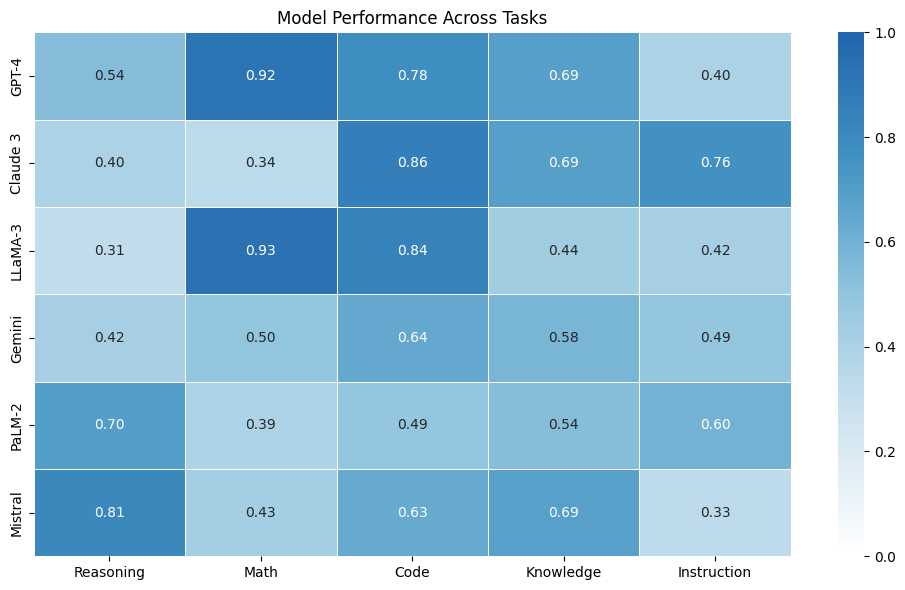

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

# Create sample data
models = ['GPT-4', 'Claude 3', 'LLaMA-3', 'Gemini', 'PaLM-2', 'Mistral']
tasks = ['Reasoning', 'Math', 'Code', 'Knowledge', 'Instruction']

# Random scores between 0.3 and 0.95
np.random.seed(42)
scores = np.random.uniform(0.3, 0.95, size=(len(models), len(tasks)))
df = pd.DataFrame(scores, index=models, columns=tasks)

# Custom colormap
colors = ["#ffffff", "#d1e5f0", "#92c5de", "#4393c3", "#2166ac"]
cmap = LinearSegmentedColormap.from_list("custom_blue", colors)

# Create the heatmap
plt.figure(figsize=(10, 6))
ax = sns.heatmap(df, annot=True, cmap=cmap, linewidths=0.5, 
                 fmt='.2f', vmin=0, vmax=1)
plt.title('Model Performance Across Tasks')
plt.tight_layout()

# Save to PDF for LaTeX inclusion
plt.savefig('model_comparison.pdf', bbox_inches='tight')

# Convert to LaTeX format
def df_to_latex_with_colors(df, caption, label, cmap=cmap):
    """
    Convert DataFrame to LaTeX with custom colors
    """
    latex = []
    latex.append(r"\begin{table}[htbp]")
    latex.append(r"\centering")
    latex.append(r"\caption{" + caption + "}")
    latex.append(r"\label{tab:" + label + "}")
    
    cols = df.columns
    latex.append(r"\begin{tabular}{l" + "c" * len(cols) + "}")
    latex.append(r"\toprule")
    
    # Add header
    header = r"Model & " + " & ".join(cols) + r" \\"
    latex.append(header)
    latex.append(r"\midrule")
    
    # Add rows with coloring
    for model in df.index:
        row = [model]
        for col in cols:
            val = df.loc[model, col]
            norm_val = (val - 0) / (1 - 0)
            r, g, b, _ = cmap(norm_val)
            r, g, b = int(r*255), int(g*255), int(b*255)
            cell = r"\cellcolor[RGB]{%d,%d,%d} %.2f" % (r, g, b, val)
            row.append(cell)
        latex.append(" & ".join(row) + r" \\")
    
    latex.append(r"\bottomrule")
    latex.append(r"\end{tabular}")
    latex.append(r"\end{table}")
    
    return "\n".join(latex)

latex_table = df_to_latex_with_colors(df, 
                                      caption="Performance Comparison Across Models and Tasks", 
                                      label="model_comparison")

# Write to file
with open('tasks_table_seaborn.tex', 'w') as f:
    f.write(latex_table)

In [16]:
import pandas as pd
import numpy as np

def create_latex_table_with_circles(data, output_file='circle_table.tex', 
                                    filled_threshold=0.5, title=None):
    """
    Generate a LaTeX table with discrete circle indicators.
    
    Parameters:
    -----------
    data : pandas DataFrame
        DataFrame with model names as index and task names as columns,
        with values indicating level of attribute (0-1 or binary)
    output_file : str
        Path to save the LaTeX file
    filled_threshold : float
        Threshold above which to use a filled circle
    title : str
        Table caption
    """
    # Create a copy to avoid modifying the original
    df = data.copy()
    
    # Start LaTeX document
    latex = []
    latex.append(r"\documentclass{article}")
    latex.append(r"\usepackage{booktabs}")
    latex.append(r"\usepackage{colortbl}")
    latex.append(r"\usepackage{xcolor}")
    latex.append(r"\usepackage{tikz}")
    latex.append(r"\usepackage{amssymb}") # For math symbols
    
    # Define circle symbols
    latex.append(r"\newcommand{\fullcircle}{{\tikz\fill[black] (0,0) circle (0.1cm);}}")
    latex.append(r"\newcommand{\mediumcircle}{{\tikz\fill[black!70] (0,0) circle (0.1cm);}}")
    latex.append(r"\newcommand{\lightcircle}{{\tikz\fill[black!40] (0,0) circle (0.1cm);}}")
    latex.append(r"\newcommand{\emptycircle}{{\tikz\draw[black] (0,0) circle (0.1cm);}}")
    latex.append(r"\newcommand{\nocircle}{{$\cdot$}}")
    
    latex.append(r"\begin{document}")
    
    if title:
        latex.append(r"\begin{table}")
        latex.append(r"\centering")
        latex.append(r"\caption{" + title + "}")
        latex.append(r"\label{tab:model_comparison}")
    
    # Table header
    cols = df.columns
    ncols = len(cols)
    
    # Start tabular environment
    latex.append(r"\begin{tabular}{l" + "c" * ncols + "}")
    latex.append(r"\toprule")
    
    # Column headers
    header = r"Model & " + " & ".join(cols) + r" \\"
    latex.append(header)
    latex.append(r"\midrule")
    
    # Process rows
    for model in df.index:
        row = [model]
        for col in cols:
            value = df.loc[model, col]
            
            if pd.isna(value):
                cell = r"\nocircle"
            else:
                # Discrete categorization based on value
                if value > 0.8:
                    cell = r"\fullcircle"
                elif value > 0.6:
                    cell = r"\mediumcircle"
                elif value > 0.4:
                    cell = r"\lightcircle"
                elif value > 0:
                    cell = r"\emptycircle"
                else:
                    cell = r"\nocircle"
            
            row.append(cell)
        
        latex.append(" & ".join(row) + r" \\")
    
    # Close table
    latex.append(r"\bottomrule")
    latex.append(r"\end{tabular}")
    
    # Add legend
    latex.append(r"\vspace{0.5cm}")
    latex.append(r"\begin{tabular}{ll}")
    latex.append(r"\fullcircle & Strong capability (>80\%) \\")
    latex.append(r"\mediumcircle & Good capability (60-80\%) \\")
    latex.append(r"\lightcircle & Moderate capability (40-60\%) \\")
    latex.append(r"\emptycircle & Limited capability (<40\%) \\")
    latex.append(r"\nocircle & No capability \\")
    latex.append(r"\end{tabular}")
    
    if title:
        latex.append(r"\end{table}")
    
    latex.append(r"\end{document}")
    
    # Write to file
    with open(output_file, 'w') as f:
        f.write('\n'.join(latex))
    
    return '\n'.join(latex)

# Example usage
# Create sample data - models and tasks
models = ["gpt-4o", "gpt-4o-mini", "Llama-3.3-70B", "o3-mini", "claude-3-5-sonnet-latest"]
tasks = ["Legal Materiality", "Ag and Bio", "Japanese Nuance", "Cultural Facts", "Researcher Persona"]

# Generate discrete scores where some are clearly better
np.random.seed(42)
scores = np.random.uniform(0, 1, size=(len(models), len(tasks)))

# Make some scores clearly better/worse for demonstration
for i in range(len(models)):
    # Each model is excellent at at least one task
    scores[i, i % len(tasks)] = 0.95
    # Each model is weak at at least one task
    scores[i, (i + 2) % len(tasks)] = 0.25

df = pd.DataFrame(scores, index=models, columns=tasks)

# Create LaTeX table
latex_output = create_latex_table_with_circles(
    df, 
    title='Model Capabilities Across Different Tasks',
    output_file='discrete_circles_table.tex'
)

# Alternatively - a simpler binary version with just filled or empty circles
def create_binary_circle_table(data, output_file='binary_circle_table.tex', threshold=0.5, title=None):
    """
    Generate a LaTeX table with binary circle indicators (filled or empty).
    """
    # Create a copy to avoid modifying the original
    df = data.copy()
    binary_df = df > threshold
    
    # Start LaTeX document
    latex = []
    latex.append(r"\documentclass{article}")
    latex.append(r"\usepackage{booktabs}")
    latex.append(r"\usepackage{tikz}")
    
    # Define circle symbols
    latex.append(r"\newcommand{\fullcircle}{{\tikz\fill[black] (0,0) circle (0.1cm);}}")
    latex.append(r"\newcommand{\emptycircle}{{\tikz\draw[black] (0,0) circle (0.1cm);}}")
    
    latex.append(r"\begin{document}")
    
    if title:
        latex.append(r"\begin{table}")
        latex.append(r"\centering")
        latex.append(r"\caption{" + title + "}")
        latex.append(r"\label{tab:model_comparison}")
    
    # Table header
    cols = df.columns
    ncols = len(cols)
    
    # Start tabular environment
    latex.append(r"\begin{tabular}{l" + "c" * ncols + "}")
    latex.append(r"\toprule")
    
    # Column headers
    header = r"Model & " + " & ".join(cols) + r" \\"
    latex.append(header)
    latex.append(r"\midrule")
    
    # Process rows
    for model in binary_df.index:
        row = [model]
        for col in binary_df.columns:
            value = binary_df.loc[model, col]
            cell = r"\fullcircle" if value else r"\emptycircle"
            row.append(cell)
        
        latex.append(" & ".join(row) + r" \\")
    
    # Close table
    latex.append(r"\bottomrule")
    latex.append(r"\end{tabular}")
    
    # Add legend
    latex.append(r"\vspace{0.5cm}")
    latex.append(r"\begin{tabular}{ll}")
    latex.append(r"\fullcircle & Feature present")
    latex.append(r"\end{tabular}")
    
    if title:
        latex.append(r"\end{table}")
    
    latex.append(r"\end{document}")
    
    # Write to file
    with open(output_file, 'w') as f:
        f.write('\n'.join(latex))
    
    return '\n'.join(latex)

# Create binary version too
binary_output = create_binary_circle_table(
    df, 
    title='Model Capabilities (Binary Representation)',
    output_file='binary_circles_table.tex',
    threshold=0.6  # Threshold for considering capability present
)

In [31]:
import pandas as pd
import numpy as np

def create_latex_table_with_circles(data, output_file='circle_table.tex', 
                                   title=None, blue_color='blue!80!black'):
    """
    Generate a LaTeX table with discrete blue circle indicators and bottom caption.
    
    Parameters:
    -----------
    data : pandas DataFrame
        DataFrame with model names as index and task names as columns
    output_file : str
        Path to save the LaTeX file
    title : str
        Table caption to appear at the bottom
    blue_color : str
        LaTeX color specification for the circles
    """
    # Create a copy to avoid modifying the original
    df = data.copy()
    
    # Start LaTeX document
    latex = []
    latex.append(r"\documentclass{article}")
    latex.append(r"\usepackage{booktabs}")
    latex.append(r"\usepackage{colortbl}")
    latex.append(r"\usepackage{xcolor}")
    latex.append(r"\usepackage{tikz}")
    latex.append(r"\usepackage{amssymb}") # For math symbols
    
    # Define circle symbols with darker blue color - slightly larger (0.12cm instead of 0.1cm)
    latex.append(f"\\newcommand{{\\fullcircle}}{{{{\\tikz\\fill[{blue_color}] (0,0) circle (0.12cm);}}}}")
    latex.append(f"\\newcommand{{\\mediumcircle}}{{{{\\tikz\\fill[{blue_color}!70] (0,0) circle (0.12cm);}}}}")
    latex.append(f"\\newcommand{{\\lightcircle}}{{{{\\tikz\\fill[{blue_color}!40] (0,0) circle (0.12cm);}}}}")
    latex.append(f"\\newcommand{{\\emptycircle}}{{{{\\tikz\\draw[{blue_color}] (0,0) circle (0.12cm);}}}}")
    latex.append(r"\newcommand{\nocircle}{{$\cdot$}}")
    
    latex.append(r"\begin{document}")
    
    if title:
        latex.append(r"\begin{table}")
        latex.append(r"\centering")
    
    # Table header
    cols = df.columns
    ncols = len(cols)
    
    # Start tabular environment
    latex.append(r"\begin{tabular}{l" + "c" * ncols + "}")
    latex.append(r"\toprule")
    
    # Column headers
    header = r"Model & " + " & ".join(cols) + r" \\"
    latex.append(header)
    latex.append(r"\midrule")
    
    # Process rows
    for model in df.index:
        row = [model]
        for col in cols:
            value = df.loc[model, col]
            
            if pd.isna(value):
                cell = r"\nocircle"
            else:
                # Discrete categorization based on value
                if value > 0.8:
                    cell = r"\fullcircle"
                elif value > 0.6:
                    cell = r"\mediumcircle"
                elif value > 0.4:
                    cell = r"\lightcircle"
                elif value > 0:
                    cell = r"\emptycircle"
                else:
                    cell = r"\nocircle"
            
            row.append(cell)
        
        latex.append(" & ".join(row) + r" \\")
    
    # Close table
    latex.append(r"\bottomrule")
    latex.append(r"\end{tabular}")
    
    # Add legend
    latex.append(r"\vspace{0.5cm}")
    latex.append(r"\begin{tabular}{ll}")
    latex.append(r"\fullcircle & Strong capability (>80\%) \\")
    latex.append(r"\mediumcircle & Good capability (60-80\%) \\")
    latex.append(r"\lightcircle & Moderate capability (40-60\%) \\")
    latex.append(r"\emptycircle & Limited capability (<40\%) \\")
    latex.append(r"\nocircle & No capability \\")
    latex.append(r"\end{tabular}")
    
    # Add caption at the bottom
    if title:
        latex.append(r"\caption{" + title + "}")
        latex.append(r"\label{tab:model_comparison}")
        latex.append(r"\end{table}")
    
    latex.append(r"\end{document}")
    
    # Write to file
    with open(output_file, 'w') as f:
        f.write('\n'.join(latex))
    
    return '\n'.join(latex)

# Example usage
# Create sample data - models and tasks
models = ["gpt-4o", "gpt-4o-mini", "Llama-3.3-70B", "o3-mini", "claude-3-5-sonnet-latest"]
tasks = ["Legal Materiality", "Ag and Bio", "Japanese Nuance", "Cultural Facts", "Researcher Persona"]

# Generate discrete scores where some are clearly better
np.random.seed(42)
scores = np.random.uniform(0, 1, size=(len(models), len(tasks)))

# Make some scores clearly better/worse for demonstration
for i in range(len(models)):
    # Each model is excellent at at least one task
    scores[i, i % len(tasks)] = 0.95
    # Each model is weak at at least one task
    scores[i, (i + 2) % len(tasks)] = 0.25

df = pd.DataFrame(scores, index=models, columns=tasks)

# Create LaTeX table with blue circles and bottom caption
latex_output = create_latex_table_with_circles(
    df, 
    title='Model Capabilities Across Different Tasks',
    output_file='blue_circles_table.tex',
    blue_color='blue!80!black'  # Darker blue color
)

# Binary version with blue circles
def create_binary_circle_table(data, output_file='binary_circle_table.tex', 
                              threshold=0.5, title=None, blue_color='blue!80!black'):
    """
    Generate a LaTeX table with binary blue circle indicators and bottom caption.
    """
    # Create a copy to avoid modifying the original
    df = data.copy()
    binary_df = df > threshold
    
    # Start LaTeX document
    latex = []
    latex.append(r"\documentclass{article}")
    latex.append(r"\usepackage{booktabs}")
    latex.append(r"\usepackage{tikz}")
    latex.append(r"\usepackage{xcolor}")
    
    # Define circle symbols with darker blue color - slightly larger (0.12cm instead of 0.1cm)
    latex.append(f"\\newcommand{{\\fullcircle}}{{{{\\tikz\\fill[{blue_color}] (0,0) circle (0.12cm);}}}}")
    latex.append(f"\\newcommand{{\\emptycircle}}{{{{\\tikz\\draw[{blue_color}] (0,0) circle (0.12cm);}}}}")
    
    latex.append(r"\begin{document}")
    
    if title:
        latex.append(r"\begin{table}")
        latex.append(r"\centering")
    
    # Table header
    cols = df.columns
    ncols = len(cols)
    
    # Start tabular environment
    latex.append(r"\begin{tabular}{l" + "c" * ncols + "}")
    latex.append(r"\toprule")
    
    # Column headers
    header = r"Model & " + " & ".join(cols) + r" \\"
    latex.append(header)
    latex.append(r"\midrule")
    
    # Process rows
    for model in binary_df.index:
        row = [model]
        for col in binary_df.columns:
            value = binary_df.loc[model, col]
            cell = r"\fullcircle" if value else r"\emptycircle"
            row.append(cell)
        
        latex.append(" & ".join(row) + r" \\")
    
    # Close table
    latex.append(r"\bottomrule")
    latex.append(r"\end{tabular}")
    
    # Add legend
    latex.append(r"\vspace{0.5cm}")
    latex.append(r"\begin{tabular}{ll}")
    latex.append(r"\fullcircle & Task Elicited \\")
    latex.append(r"\end{tabular}")
    
    # Add caption at the bottom
    if title:
        latex.append(r"\caption{" + title + "}")
        latex.append(r"\label{tab:model_comparison}")
        latex.append(r"\end{table}")
    
    latex.append(r"\end{document}")
    
    # Write to file
    with open(output_file, 'w') as f:
        f.write('\n'.join(latex))
    
    return '\n'.join(latex)

# Create binary version too with blue circles
binary_output = create_binary_circle_table(
    df, 
    title='Model Capabilities (Binary Representation)',
    output_file='binary_blue_circles_table.tex',
    threshold=0.6,  # Threshold for considering capability present
    blue_color='blue!50!black'  # Navy blue color
)

In [43]:
def create_colored_task_table(
    data, 
    output_file='colored_task_table.tex', 
    title=None,
    task_colors=None,
    task_descriptions=None
):
    """
    Generate a LaTeX table with colored circles for different task categories.
    Tasks are rows, models are columns.
    
    Parameters:
    -----------
    data : pandas DataFrame
        DataFrame with tasks as index and model names as columns, with binary values
    output_file : str
        Path to save the LaTeX file
    title : str
        Table caption
    task_colors : dict
        Dictionary mapping task categories to their colors in LaTeX format
    task_descriptions : dict
        Dictionary mapping task names to their descriptions for the caption
    """
    df = data.copy()
    
    latex = []
    latex.append(r"\documentclass{article}")
    latex.append(r"\usepackage{booktabs}")
    latex.append(r"\usepackage{tikz}")
    latex.append(r"\usepackage{xcolor}")
    latex.append(r"\usepackage{graphicx}")
    
    latex.append(r"\newcommand{\fullcircle}{\tikz\fill[black] (0,0) circle (0.15cm);}")
    latex.append(r"\newcommand{\emptycircle}{\tikz\draw[black] (0,0) circle (0.15cm);}")
    
    for task_category, color in task_colors.items():
        color_name = task_category.lower().replace(" ", "_")
        latex.append(f"\\newcommand{{\\full{color_name}}}{{{{\\tikz\\fill[{color}] (0,0) circle (0.15cm);}}}}")
        latex.append(f"\\newcommand{{\\empty{color_name}}}{{{{\\tikz\\draw[{color}] (0,0) circle (0.15cm);}}}}")
  
    latex.append(r"\begin{document}")
    
    if title:
        latex.append(r"\begin{table}")
        latex.append(r"\centering")
        latex.append(r"\small")
    
    models = df.columns
    tasks = df.index
    
    latex.append(r"\begin{tabular}{l" + "c" * len(models) + "}")
    latex.append(r"\toprule")
    
    header_cells = ["Task"]
    for model in models:
        if len(model) > 12:
            parts = model.split("-")
            model_header = r"\shortstack{" + r"\\".join(parts) + r"}"
        else:
            model_header = model
        header_cells.append(model_header)
    
    header = " & ".join(header_cells) + r" \\"
    latex.append(header)
    latex.append(r"\midrule")
    
    for task in tasks:
        task_category = task.split(" ")[0]
        color_name = task_category.lower().replace(" ", "_")
        
        row = [task]
        for model in models:
            value = df.loc[task, model]
            cell = f"\\full{color_name}" if value else f"\\empty{color_name}"
            row.append(cell)
        
        latex.append(" & ".join(row) + r" \\")
    
    latex.append(r"\bottomrule")
    latex.append(r"\end{tabular}")
    
    latex.append(r"\vspace{0.5cm}")
    latex.append(r"\begin{tabular}{ll}")
    latex.append(r"\fullcircle & Task Elicited (= model struggles on task) \quad \emptycircle & Task Not Elicited \\")
    latex.append(r"\end{tabular}")
    
    if title:
        caption = r"\caption{\small " + title
        
        if task_descriptions:
            caption += " \\textit{"
            descriptions = [f"{task} = {desc}" for task, desc in task_descriptions.items()]
            caption += "; ".join(descriptions)
            caption += "}"
        
        caption += "}"
        latex.append(caption)
        latex.append(r"\label{tab:model_comparison}")
        latex.append(r"\end{table}")
    
    latex.append(r"\end{document}")
    
    with open(output_file, 'w') as f:
        f.write('\n'.join(latex))
    
    return '\n'.join(latex)

# Example usage with transposed data and task categories
models = ["gpt-4o", "gpt-4o-mini", "Llama-3.3-70B", "o3-mini", "claude-3-5-sonnet-latest"]

base_tasks = [
    "Legal Materiality", "Legal Materiality (to be updated)", 
    "Ag and Bio", "Ag and Bio (to be updated)",
    "Japanese Nuance", "Japanese Nuance (to be updated)",
    "Cultural Facts", "Cultural Facts (to be updated)",
    "Researcher Persona", "Researcher Persona (to be updated)"
]

task_colors = {
    "Legal": "red!80!black",
    "Ag": "green!80!black",
    "Japanese": "blue!80!black",
    "Cultural": "purple!80!black",
    "Researcher": "orange!80!black"
}

binary_data = {
    "gpt-4o": [True, True, True, True, False, False, False, False, False, False],
    "gpt-4o-mini": [False, False, True, True, True, True, False, False, True, True],
    "Llama-3.3-70B": [False, False, True, True, True, True, False, False, False, False],
    "o3-mini": [False, False, False, False, False, False, True, True, False, False],
    "claude-3-5-sonnet-latest": [True, True, False, False, False, False, False, False, True, True]
}

binary_df = pd.DataFrame(binary_data, index=base_tasks)

task_descriptions = {
    "Legal Materiality": "Struggles with handling nuanced in deciding materiality in contracts",
    "Legal Materiality (to be updated)": "Struggles with handling nuanced in deciding materiality in contracts",
    "Ag and Bio": "Confuses connection between advancements in agricultural and biotechnology",
    "Ag and Bio (to be updated)": "Confuses connection between advancements in agricultural and biotechnology",
    "Japanese Nuance": "Struggles with classifying politeness in the context of Japanese language nuances",
    "Japanese Nuance (to be updated)": "Struggles with classifying politeness in the context of Japanese language nuances",
    "Cultural Facts": "Confused between agreed upon cultural facts and actual truths",
    "Cultural Facts (to be updated)": "Confused between agreed upon cultural facts and actual truths",
    "Researcher Persona": "Can elicit instances of targeted bullying when the attacker pretends to be a researcher",
    "Researcher Persona (to be updated)": "Can elicit instances of targeted bullying when the attacker pretends to be a researcher",
}

latex_output = create_colored_task_table(
    binary_df,
    title='Tasks elicited by gpt-4o to profile five models.',
    output_file='colored_task_table.tex',
    task_colors=task_colors,
    task_descriptions=task_descriptions
)